max deviation between Leb_wrong and mc_Leb_wrong: 0.5204185285682519
max deviation between test error and population error: 0.23055544301545366


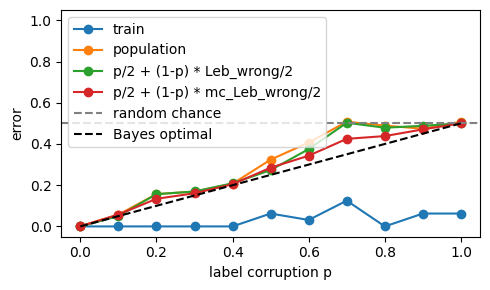

In [8]:
import numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng_xtr = np.random.default_rng(4)
rng_xte = np.random.default_rng(5)     # different RNGs for train/test/corruption: so if we increase n_train or n_test, inputs and corrupted labels for first n_train/n_test points does not change (otw consumes more RNG calls)
rng_ytr = np.random.default_rng(6)
rng_yte = np.random.default_rng(7)

n_train, n_test = 32, 1000 # n_test large enough to sample [-1,1] with high resolution and get accurate test error estimate
width = 1024  # wide enough to interpolate at p=1 (n_train << width)
ps = np.linspace(0, 1.0, 11) # label corruption levels to sweep over

epochs=100_000
lr=1e-3

early_stop = True
nb_errors_allowed = 0               # early stop if <= this many errors
freq_check = 100                     # check early stop every freq_check epochs

train_err, test_err, Leb_wrongs, mc_Leb_wrongs = [], [], [], []

for p in ps:
    # data = {(x, y)} with x~Unif([-1,1]), y = sign(x) with proba 1-p, y = Unif({0,1}) otw
    xtr = rng_xtr.uniform(-1, 1, (n_train, 1)).astype(np.float32)
    ytr = (xtr[:, 0] > 0).astype(np.float32)[:, None]

    xte = rng_xte.uniform(-1, 1, (n_test, 1)).astype(np.float32)
    yte = (xte[:, 0] > 0).astype(np.float32)[:, None]

    # corrupt train and test labels: pick exactly ceil(p * n_train) labels y to replace with Unif({0, 1})
    mask_ytr = rng_ytr.choice(n_train, size=int(np.ceil(p * n_train)), replace=False)
    mask_yte = rng_yte.choice(n_test, size=int(np.ceil(p * n_test)), replace=False)
    if mask_ytr.size > 0:
        ytr[mask_ytr] = rng_ytr.integers(0, 2, mask_ytr.size).astype(np.float32)[:, None]
    if mask_yte.size > 0:
        yte[mask_yte] = rng_yte.integers(0, 2, mask_yte.size).astype(np.float32)[:, None]

    xtr = torch.tensor(xtr)
    ytr = torch.tensor(ytr, dtype=torch.long).squeeze()
    xte = torch.tensor(xte)
    yte = torch.tensor(yte, dtype=torch.long).squeeze()


    net = nn.Sequential(nn.Linear(1, width), nn.ReLU(), nn.Linear(width, 2))
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    # train until (almost) perfect fit
    for t in range(epochs):
        opt.zero_grad()
        logits = net(xtr)
        loss = F.cross_entropy(logits, ytr)
        loss.backward()
        opt.step()

        if early_stop and (t % freq_check == 0):
            with torch.no_grad():
                tr_err_now = (net(xtr).argmax(dim=1) != ytr).float().sum().item()
            if tr_err_now <= nb_errors_allowed:
                break

    with torch.no_grad():
        tr_err = (net(xtr).argmax(1) != ytr).float().mean().item()
        te_err = (net(xte).argmax(1) != yte).float().mean().item()

        # compute approximate Leb_wrong via Monte Carlo sampling, so we'll be able to 
        # assess whether the difference between Leb_wrong and te_err is of the same order 
        # to te_err being a Monte Carlo estimate of population error or not
        pred_sign = torch.sign(net(xte)[:,1] - net(xte)[:,0])
        true_sign = torch.sign(xte.squeeze())
        approx_Leb_wrong = (pred_sign != true_sign).float().mean().item()

        w = net[0].weight[:, 0]
        b = net[0].bias
        v = net[2].weight[1, :] - net[2].weight[0, :] # logit gap(x) = f_2(x) - f_1(x) = v^T ReLU(w x + b)

        # breakpoints are the -b_j / w_j inside (-1, 1)
        mask_w = (w.abs() > 1e-12) # if w_j ≈ 0, contributes a constant ReLU(b_j) to the output so no breakpoint (and it's a dead neuron if b_j < 0: could be removed)
        bk = (-b[mask_w] / w[mask_w]).cpu().numpy()
        bk = np.unique(bk[(bk > -1) & (bk < 1)])
        bk = np.concatenate(([-1], bk, [1]))

        Leb_wrong = 0.0

        for i in range(len(bk) - 1):
            l, r = float(bk[i]), float(bk[i + 1]) # interval [left, right]

            mid = 0.5 * (l + r)
            act = ((w * mid + b) > 0).to(w.dtype)  # which ReLU neurons are active on this region
            # logit gap(x) = f_2(x) - f_1(x) = m * x + c on this region
            m = (v * act * w).sum().item()
            c = (v * act * b).sum().item()

            # Leb( sign(Delta(x)) != sign(x) )
            cuts = [(l, r)]
            if l < 0 < r:
                cuts = [(l, 0.0), (0.0, r)]
            for (ll, rr) in cuts:
                true_sign = (-1 if rr <= -1e-12 else (1 if ll >= 1e-12 else 0)) 
                if true_sign == 0:
                    continue

                if abs(m) <= 1e-12:
                    # constant Delta(x) = c on this interval
                    if c * true_sign < -1e-12: # if c has opposite sign of true_sign, count the whole interval as wrong
                        Leb_wrong += (rr - ll)
                else:
                    x0 = -c / m # zero of mx+c, where it changes sign on that region
                    if m > 0:
                        pos_subinterval = max(0.0, rr - max(ll, x0)) # positive on x > x0
                    else:
                        pos_subinterval = max(0.0, min(rr, x0) - ll) # positive on x < x0
                    Leb_wrong += pos_subinterval if true_sign == -1 else (rr - ll - pos_subinterval)


    train_err.append(tr_err); test_err.append(te_err); Leb_wrongs.append(Leb_wrong); mc_Leb_wrongs.append(approx_Leb_wrong)

print(f"max deviation between Leb_wrong and mc_Leb_wrong: {np.max(np.array(Leb_wrongs) - np.array(mc_Leb_wrongs))}")
pop_error = ps / 2 + (1 - ps) * np.array(Leb_wrongs)/2
print(f"max deviation between test error and population error: {np.max(np.array(test_err) - np.array(Leb_wrongs))}")

plt.figure(figsize=(5,3))
plt.plot(ps, train_err, "o-", label="train")
plt.plot(ps, test_err, "o-", label="population")
plt.plot(ps, pop_error, "o-", label="p/2 + (1-p) * Leb_wrong/2")
plt.plot(ps, ps / 2 + (1 - ps) * np.array(mc_Leb_wrongs)/2, "o-", label="p/2 + (1-p) * mc_Leb_wrong/2")
plt.axhline(0.5, ls="--", color="gray", label="random chance")
plt.plot(ps, ps/2, "k--", label="Bayes optimal")  # Bayes error = p/2
plt.xlabel("label corruption p")
plt.ylabel("error")
# plt.title("train/population error vs label corruption")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

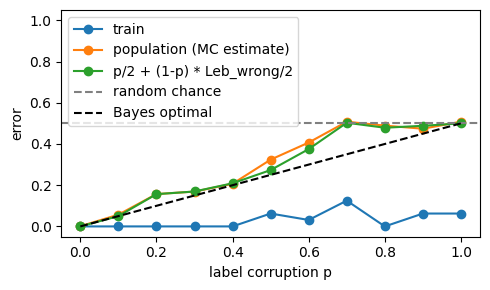

In [9]:
plt.figure(figsize=(5,3))
plt.plot(ps, train_err, "o-", label="train")
plt.plot(ps, test_err, "o-", label="population (MC estimate)")
plt.plot(ps, pop_error, "o-", label="p/2 + (1-p) * Leb_wrong/2")
plt.axhline(0.5, ls="--", color="gray", label="random chance")
plt.plot(ps, ps/2, "k--", label="Bayes optimal")  # Bayes error = p/2
plt.xlabel("label corruption p")
plt.ylabel("error")
# plt.title("train/population error vs label corruption")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()